# Issue 6b: ESMFold2 Prediction Graph Distributions.

> **Author:** Alexander Leonardos\
> **Date Started:** July 29th, 2026\
> **Date Finished:** July 30th, 2026 NOTE: This is just the validation that the graphs show up properly using test sets, NOT that the actual analysis is fully done.\
> **Input:** `s3://petadex-protein-structures/esmfold2-centroids/`\
> **Output:** Graph analysis.

---

## Objective

The goal of this notebook is to graph the following sub-experiment:

### Group B: This set of figures compares Base vs MSA (Does adding the MSAs do anything? This should be run over the full centroids)

- [ ] **Ba.** *Does MSA affect TM-Score?*: TM-score(base_pred, msa_pred)

- [ ] **Bb**. *Does MSA affect molecular feasibility distributions?*: Overlaid distributions of Molprobity(base_pred) and Molprobity(msa_pred)

- [ ] **Bc**. *Does MSA affect molecular feasibility (pointwise)?*: Molprobity score of the predicted structure itself as the coordinate
  - Concretely, x coord: Molprobity(base_pred), y coord: Molprobity(msa_pred)
  - want points below y=x, as lower molprobity is better
  - Same data as Bb, but it is a pointwise comparison


## Note

For this initial commit, outputs from experiment A will be used as the test data.

Set 1: `s3://petadex-protein-structures/esmfold2_paramsweep/s100_l20/` (will be the full baseline folds)

Set 2: `s3://petadex-protein-structures/esmfold2_paramsweep/s32_l5/` (will be the MSA folds)

## 0. Deps

In [1]:
# Install the required packages with the versions used for the analysis.
import sys, subprocess

PACKAGES = [
    # this notebook (figures) + pair_tm.py (scoring)
    "numpy==2.4.6",
    "matplotlib==3.11.1",
    "tmtools==0.3.0",          # TM-align; pair_tm.py --metric tmalign
    "boto3==1.43.56",
    "botocore==1.43.56",
    "biopython==1.87",         # only for pair_tm.py --parser biopython (the cross-check path)
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PACKAGES], check=True)
print("installed:", ", ".join(PACKAGES))

installed: numpy==2.4.6, matplotlib==3.11.1, tmtools==0.3.0, boto3==1.43.56, botocore==1.43.56, biopython==1.87


## 1. Config + paths

Group B compares **two prediction runs of the same ORFs**: run A (baseline) vs run B (the
MSA-conditioned folds). No ground-truth PDB is involved, so every folded ORF counts — not just the
121 with a solved structure that experiment A was restricted to.

**The MSA folds do not exist yet.** Until they do, the two stand-in prefixes are experiment A's
`s100_l20` and `s32_l5` param configs, which fold the same 121 ORFs. That makes this a real
end-to-end test of the tooling, but *not* a real Ba result: 6a already established those two configs
agree to TM ≈ 0.99, so the figures below should come out degenerate (a spike at 1.0). That is the
expected outcome here — it validates the axes, the zoom panel, and the aggregates, and it is why the
zoom window is derived from the data rather than hardcoded. Swap `S3_RUN_B` for the MSA prefix when
it lands; nothing else in the notebook changes.

In [2]:
from pathlib import Path

# --- the two runs being compared ------------------------------------------------------------------
S3_ROOT  = "s3://petadex-protein-structures/esmfold2_paramsweep/"
S3_RUN_A = S3_ROOT + "s100_l20/"    # STAND-IN for the base folds     (-> the real baseline prefix)
S3_RUN_B = S3_ROOT + "s32_l5/"      # STAND-IN for the MSA folds      (-> the real MSA prefix)
LABEL_A, LABEL_B = "base", "msa"

# locate repo root (dir containing resources/) from wherever the kernel started
REPO = Path.cwd()
while not (REPO / "resources").exists() and REPO != REPO.parent:
    REPO = REPO.parent
RES = REPO / "resources" / "260729_issue6b_folddistributions"
PAIR_TM = RES / "pair_tm.py"
OUT_BA  = RES / f"pairtm_{LABEL_A}_vs_{LABEL_B}"      # ledger + aggregates land here

assert PAIR_TM.exists(), f"pair_tm.py not found: {PAIR_TM}"
print("repo:", REPO)
print("A   :", S3_RUN_A)
print("B   :", S3_RUN_B)
print("out :", OUT_BA)

repo: c:\Users\27leo\VSCode\igem-toronto
A   : s3://petadex-protein-structures/esmfold2_paramsweep/s100_l20/
B   : s3://petadex-protein-structures/esmfold2_paramsweep/s32_l5/
out : c:\Users\27leo\VSCode\igem-toronto\resources\260729_issue6b_folddistributions\pairtm_base_vs_msa


In [ ]:
# The predictions bucket is PRIVATE -- pair_tm.py needs signed creds to stream from it.
# Run these in PowerShell/WSL first (the same temp STS keys used for the VM uploads); a 403 or
# ExpiredToken in the next cell means these need refreshing.
"""
aws configure set aws_access_key_id <your-access-key-id>
aws configure set aws_secret_access_key <your-secret-access-key>
aws configure set aws_session_token <your-session-token>      # if using temporary credentials
aws configure set default.region us-east-1
"""

# Ba

**Ba.** *Does MSA affect TM-score?* — `TM-score(base_pred, msa_pred)`, one score per shared ORF.

### What is being measured

Both runs fold the *same* sequence, so this is a paired, run-vs-run structural comparison. It answers
**"did conditioning on an MSA move the fold at all?"** — and nothing more:

- **TM ≈ 1 means the change was inert**, not that it was good. A low TM means "different fold", not
  "worse fold". Which one is *more accurate* needs experimental references — that is group C.
- Both normalisations are recorded (`tm_norm_a`/`tm_norm_b`); for equal-length pairs they agree, and
  they diverge only if one run truncated differently. The figures use `tm_min` (the pessimistic one).

### Which metric, and why it is not TM-align by default

Two folds of the **same sequence** have a **known 1:1 residue correspondence**, so a Kabsch
superposition over that correspondence is *exact* — not an approximation. TM-align's ability to find
its own correspondence is only *needed* when the sequences differ (one run truncated, or the wrong
prefix was passed). The two differ enormously in cost, measured on this pipeline's own structures:

| length | TM-align | Kabsch |
|---|---|---|
| 150 aa | 12 ms | 0.12 ms |
| 300 aa | 40 ms | 0.10 ms |
| 600 aa | 330 ms | 0.11 ms |
| 900 aa | 1351 ms | 0.11 ms |

TM-align is roughly **cubic** in length while Kabsch is flat, so on the full centroid set the ORFs
near the 2048 aa ESMC context limit would dominate the entire run by themselves. Hence
`--metric auto` (the default): **Kabsch when the two sequences match, TM-align only when they do
not**, recorded per row in `metric_used`.

One correction to a tempting assumption: Kabsch is **not** a strict lower bound on TM-align. TM-align's
superposition is an iterative heuristic rather than a global optimum, so on near-identical structures
it can land marginally *below* the fixed-correspondence Kabsch value (measured: −5e-3). On genuinely
moved structures it exceeds Kabsch, as expected, by finding a better correspondence. Treat the
relationship as two-sided agreement of order 1e-3 in the inert regime, which is what §2d checks.

### Why this scales to millions of pairs

The test set here is ~121 pairs, but the real comparison runs over the full centroid set. Nothing in
`pair_tm.py` grows with N:

| Concern | How it is handled |
|---|---|
| Structures | streamed one GET each, parsed **from memory** — never written to disk |
| Work list | explicit id list, or the two runs' `tracker.csv` intersected — not a listing walk |
| Fan-out | `--shard K/N` (same convention as the predictor); each shard owns a disjoint id band **and its own ledger**, so fleet workers never clobber each other |
| Interruption | the ledger is append-only and re-read on start → a restart **resumes** |
| Figures | plotted from `aggregates*.json` (fixed-bin histograms + Welford moments + exact threshold counts + a seeded reservoir subsample), which is **O(1) in N** and addable across shards via `--merge` |

The per-pair TSV is a convenience for inspecting outliers, not the plotting input — so the figures
cost the same whether there are 121 pairs or 2 million.

### 2a. Validate the tooling offline first

`--self-test` fabricates two runs on disk and checks the parts that would otherwise fail silently
against real data — no S3, no creds, no GPU. It asserts:

- the fast CIF parser recovers coordinates + sequence, and **agrees with Biopython** on the same file;
- TM = 1.0 for identical *and* rigid-body-moved copies (rotation/translation invariance), < 1 when
  distorted, and Kabsch vs TM-align agree in the inert regime while TM-align legitimately exceeds
  Kabsch on genuinely moved pairs;
- `--metric auto` picks Kabsch when the sequences match and falls back to TM-align when one run
  truncated;
- the histograms sum to n, the Welford mean is exact, threshold counts are exact, and the median read
  off the bins lands within one bin width of the true median;
- an ORF missing from one run becomes `status=missing_a` instead of crashing the shard;
- re-running appends nothing (resume works), 4 shards are **disjoint and cover every pair once**, and
  the 4 shard aggregates **reassemble bin-for-bin** into the single-run aggregate.

That last group is the reason to run this before spending money: a sharding or resume bug at full
scale silently loses or double-counts pairs, and the merged histogram is the only thing the figures
ever see.

In [3]:
import subprocess, sys

r = subprocess.run([sys.executable, str(PAIR_TM), "--self-test"], capture_output=True, text=True)
print(r.stdout[-3000:])
if r.returncode != 0:
    print("!! SELF-TEST FAILED -- do not trust any figure below\n", r.stderr[-2000:])

 p50=1.000  p75=1.000  p95=1.000  p99=1.000
  fraction below:  0.5=0/10 (0.00%)  0.7=0/10 (0.00%)  0.8=0/10 (0.00%)  0.9=0/10 (0.00%)  0.95=0/10 (0.00%)  0.99=0/10 (0.00%)

  TM ~= 1 means the change was INERT (fold did not move), not that it was good.

  per-pair rows -> C:\Users\27leo\AppData\Local\Temp\tmpr502v9u5\sh\pairs.shard2of4.tsv
  aggregates    -> C:\Users\27leo\AppData\Local\Temp\tmpr502v9u5\sh\aggregates.shard2of4.json   (plot from this; O(1) in N)
run A = base   C:\Users\27leo\AppData\Local\Temp\tmpr502v9u5\runA
run B = msa   C:\Users\27leo\AppData\Local\Temp\tmpr502v9u5\runB
40 shared ORFs (work list from S3/dir listing of both runs) | only in A: 1 | only in B: 0
shard 3/4: 10/40 pairs

Ba  TM-score  'base'  vs  'msa'    n_ok=10   (0.0s)
  mean=1.0000  sd=0.0000  min=1.0000  max=1.0000
  quantiles (bin-resolution 0.005): p1=1.000  p5=1.000  p25=1.000  p50=1.000  p75=1.000  p95=1.000  p99=1.000
  fraction below:  0.5=0/10 (0.00%)  0.7=0/10 (0.00%)  0.8=0/10 (0.00%)  0.9=0

### 2b. Score the pairs

Streams both runs from S3 and writes `pairs.tsv` (one row per ORF) + `aggregates.json` (the figure
input) into `OUT_BA`.

`--metric both` on this first pass so the TM-align vs kabsch gap is measured on real predictions
rather than assumed — that is what justifies dropping to the cheap metric for the full run. The work
list comes from intersecting the two runs' `tracker.csv`; add `--ids-from-listing` if a run has no
tracker, or `--ids <file>` to pin an explicit ORFid list.

Safe to run mid-fold: ORFs not yet uploaded are recorded as `missing_a`/`missing_b` and skipped, so
re-running later picks up only what is new.

In [4]:
import subprocess, sys, time

def score_ba(run_a=S3_RUN_A, run_b=S3_RUN_B, out=OUT_BA, metric="both", workers=16, extra=()):
    """Run pair_tm.py over the two prefixes. Resumable -- re-running only scores what is missing."""
    cmd = [sys.executable, str(PAIR_TM),
           "--run-a", run_a, "--run-b", run_b,
           "--label-a", LABEL_A, "--label-b", LABEL_B,
           "--out", str(out), "--metric", metric, "--workers", str(workers), *extra]
    print(" ".join(cmd[1:]), "\n")
    t0 = time.perf_counter()
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout[-4000:])
    if r.returncode != 0:
        print("!! pair_tm.py failed\n", r.stderr[-2000:])
        return None
    print(f"[{time.perf_counter()-t0:.1f}s wall]")
    return out

score_ba()

c:\Users\27leo\VSCode\igem-toronto\resources\260729_issue6b_folddistributions\pair_tm.py --run-a s3://petadex-protein-structures/esmfold2_paramsweep/s100_l20/ --run-b s3://petadex-protein-structures/esmfold2_paramsweep/s32_l5/ --label-a base --label-b msa --out c:\Users\27leo\VSCode\igem-toronto\resources\260729_issue6b_folddistributions\pairtm_base_vs_msa --metric both --workers 16 

run A = base   s3://petadex-protein-structures/esmfold2_paramsweep/s100_l20/
run B = msa   s3://petadex-protein-structures/esmfold2_paramsweep/s32_l5/
121 shared ORFs (work list from tracker.csv of both runs)

Ba  TM-score  'base'  vs  'msa'    n_ok=121   (6.8s)
  mean=0.9767  sd=0.0332  min=0.8780  max=0.9999
  quantiles (bin-resolution 0.005): p1=0.885  p5=0.890  p25=0.970  p50=0.990  p75=0.995  p95=0.995  p99=0.995
  fraction below:  0.5=0/121 (0.00%)  0.7=0/121 (0.00%)  0.8=0/121 (0.00%)  0.9=9/121 (7.44%)  0.95=23/121 (19.01%)  0.99=53/121 (43.80%)

  TM ~= 1 means the change was INERT (fold did not 

WindowsPath('c:/Users/27leo/VSCode/igem-toronto/resources/260729_issue6b_folddistributions/pairtm_base_vs_msa')

### 2c. Figure Ba

Four panels, each answering a different question — all read from `aggregates.json`, so this cell
costs the same at any N:

1. **full-range TM histogram** (log counts, since run-vs-run TM piles up at 1.0) with the TM = 0.5
   "same fold" reference — the shape of the distribution;
2. **zoom on the top decile**, where a saturated distribution actually has structure. The window is
   the aggregates' own fine-binned zoom histogram (0.0005 bins), not a hardcoded guess;
3. **ECDF** — the panel that answers "what fraction of ORFs moved more than X?" precisely, which a
   histogram cannot;
4. **TM vs ORF length** as a 2D density — is any movement length-dependent?

With the stand-in param-config data all four should collapse toward 1.0. That is the expected
validation result, not a finding.

n=121  mean=0.9767  sd=0.0332  median~0.9950  min=0.8780  max=0.9999
  TM<0.5: 0 (0.00%)   TM<0.7: 0 (0.00%)   TM<0.8: 0 (0.00%)   TM<0.9: 9 (7.44%)   TM<0.95: 23 (19.01%)   TM<0.99: 53 (43.80%)


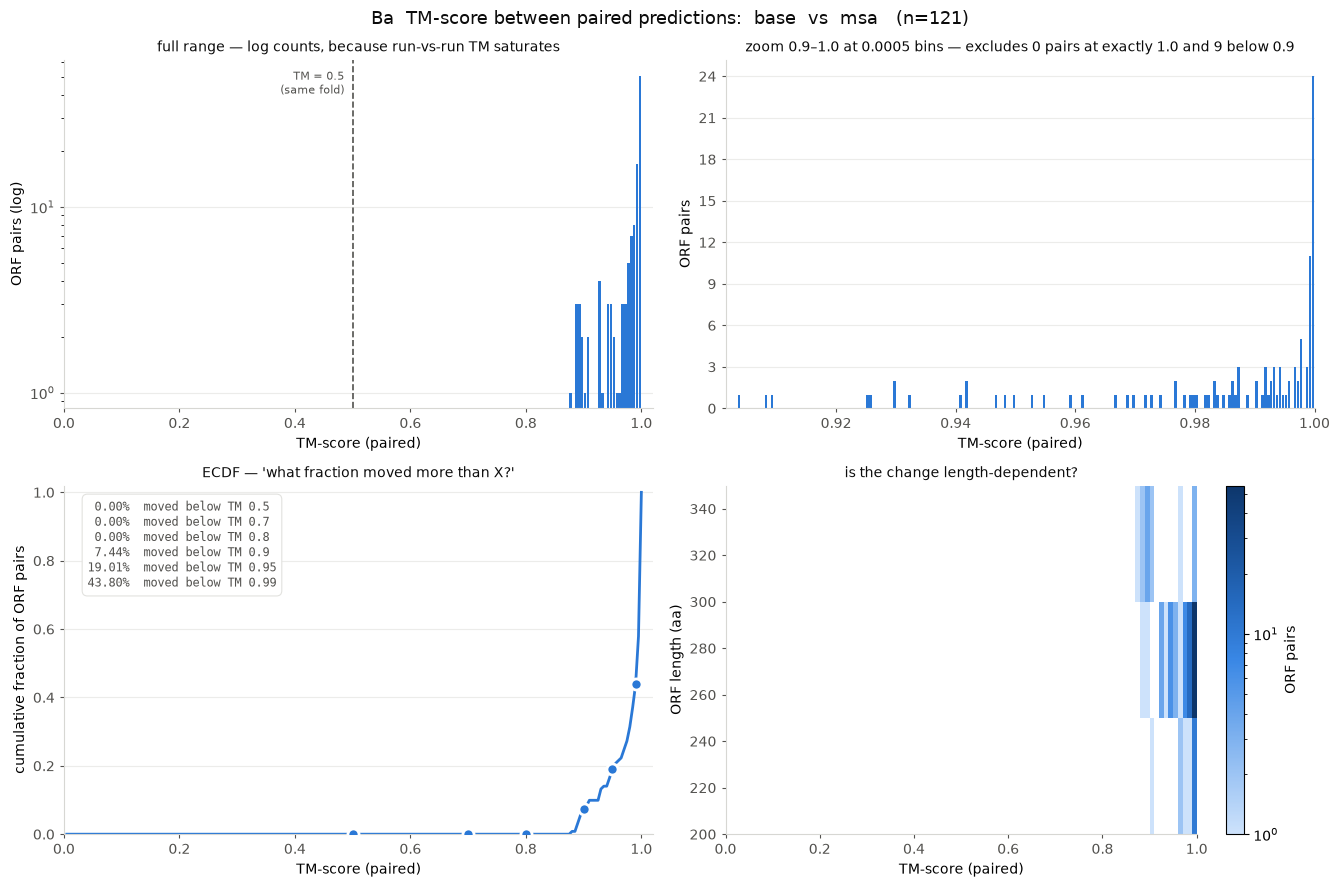

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.ticker import MaxNLocator

# Reference data-viz palette, used unchanged: categorical slot 1 (blue) for the single series,
# slot 2 (orange) reserved for run B in the Bb/Bc two-series figures, neutral ink for annotation.
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
SEQ_BLUE = LinearSegmentedColormap.from_list(       # sequential ramp, light -> dark (steps 100-700)
    "seqblue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def load_agg(out_dir):
    """Aggregates for a run: the merged file if shards were merged, else the single-run file, else
    merge the shards on the fly. Never reads the per-pair ledger."""
    out_dir = Path(out_dir)
    for name in ("aggregates.merged.json", "aggregates.json"):
        if (out_dir / name).exists():
            return json.loads((out_dir / name).read_text())
    shards = sorted(out_dir.glob("aggregates.shard*.json"))
    if not shards:
        raise FileNotFoundError(f"no aggregates*.json in {out_dir} -- run score_ba() first")
    sys.path.insert(0, str(RES))
    from pair_tm import Aggregates
    return Aggregates.merge([json.loads(p.read_text()) for p in shards])


def _tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)          # recessive axes
    for s in ax.spines.values():
        s.set_color("#d7d7d3")
    ax.tick_params(colors=MUTED, length=3)
    ax.grid(axis="y", color="#ececea", lw=0.8)
    ax.set_axisbelow(True)


def plot_ba(out_dir=OUT_BA, label_a=LABEL_A, label_b=LABEL_B):
    d = load_agg(out_dir)
    n = d["n_ok"]
    if not n:
        print("no scored pairs:", d.get("status"))
        return d
    tm_lo, tm_hi, tm_nb = d["bins"]["tm"]
    h = np.asarray(d["hist"]["tm"], dtype=float)
    body, overflow = h[:tm_nb], h[tm_nb]                    # last cell = exactly TM == 1.0
    edges = np.linspace(tm_lo, tm_hi, tm_nb + 1)
    centers, width = (edges[:-1] + edges[1:]) / 2, (tm_hi - tm_lo) / tm_nb
    disp = body.copy()
    disp[-1] += overflow                                    # fold TM==1 into the top bin for display

    below = {float(k): v for k, v in d["tm_below"].items()}
    mean, sd = d["moments"]["mean"], np.sqrt(d["moments"]["var"])
    # x for the cumulative curve = each bin's RIGHT edge, plus one final point for the exact-1.0
    # cell (which shares the coordinate 1.0 with the last bin's edge, hence the extra entry).
    cum_x = np.append(edges[1:], 1.0)
    cum = np.cumsum(np.append(body, overflow))
    med = float(cum_x[min(int(np.searchsorted(cum, 0.5 * n)), len(cum_x) - 1)])

    print(f"n={n}  mean={mean:.4f}  sd={sd:.4f}  median~{med:.4f}  "
          f"min={d['moments']['min']:.4f}  max={d['moments']['max']:.4f}")
    print("  " + "   ".join(f"TM<{t}: {v} ({100*v/n:.2f}%)" for t, v in sorted(below.items())))

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))
    fig.suptitle(f"Ba  TM-score between paired predictions:  {label_a}  vs  {label_b}   (n={n:,})",
                 fontsize=13, color=INK)

    # (1) full range -------------------------------------------------------
    ax = axes[0, 0]
    ax.bar(centers, disp, width=width * 0.9, color=BLUE, linewidth=0)
    ax.axvline(0.5, color=MUTED, ls="--", lw=1.2)
    ax.annotate("TM = 0.5\n(same fold)", (0.5, 0.97), xycoords=("data", "axes fraction"),
                xytext=(-6, 0), textcoords="offset points",   # clear of the line, not on it
                ha="right", va="top", fontsize=8, color=MUTED)
    ax.set_yscale("log")
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("TM-score (paired)"); ax.set_ylabel("ORF pairs (log)")
    ax.set_title("full range — log counts, because run-vs-run TM saturates", fontsize=10, color=INK)
    _tidy(ax)

    # (2) zoom on the top decile ------------------------------------------
    ax = axes[0, 1]
    z_lo, z_hi, z_nb = d["bins"]["tm_zoom"]
    z = np.asarray(d["hist"]["tm_zoom"], dtype=float)
    under, zbody, zover = z[0], z[1:z_nb + 1], z[z_nb + 1]
    # The exact-1.0 spike is DELIBERATELY excluded here: it is already the headline of panel 1, and
    # leaving it in flattens every other bar to invisibility. This panel's job is the pairs that
    # moved a little -- the ones only a fine binning can show.
    zedges = np.linspace(z_lo, z_hi, z_nb + 1)
    nz = np.nonzero(zbody)[0]
    ax.bar((zedges[:-1] + zedges[1:]) / 2, zbody, width=(z_hi - z_lo) / z_nb * 0.9,
           color=BLUE, linewidth=0)
    if len(nz):                                             # window from the DATA, not hardcoded
        ax.set_xlim(max(z_lo, zedges[nz[0]] - 0.002), min(z_hi, zedges[nz[-1] + 1] + 0.002))
    else:
        ax.annotate("no pairs strictly between\n0.9 and 1.0", (0.5, 0.5), xycoords="axes fraction",
                    ha="center", va="center", fontsize=9, color=MUTED)
    ax.set_xlabel("TM-score (paired)"); ax.set_ylabel("ORF pairs")
    ax.set_title(f"zoom {z_lo}–1.0 at {(z_hi-z_lo)/z_nb:.4f} bins — excludes "
                 f"{int(zover)} pairs at exactly 1.0 and {int(under)} below {z_lo}",
                 fontsize=10, color=INK)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))   # counts, never fractional
    _tidy(ax)

    # (3) ECDF -------------------------------------------------------------
    ax = axes[1, 0]
    ax.plot(cum_x, cum / n, color=BLUE, lw=2)
    # Threshold marks get ONE shared text block rather than a label each: the fractions are close
    # together on a saturated distribution, so per-point annotations collide into mush.
    for t in sorted(below):
        ax.plot([t], [below[t] / n], "o", ms=8, color=BLUE, mec="white", mew=2, zorder=3)
    ax.annotate("\n".join(f"{100*below[t]/n:5.2f}%  moved below TM {t}" for t in sorted(below)),
                (0.04, 0.96), xycoords="axes fraction", va="top", ha="left",
                fontsize=8.5, color=MUTED, family="monospace",
                bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#e2e2df", lw=0.8))
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.set_xlabel("TM-score (paired)"); ax.set_ylabel("cumulative fraction of ORF pairs")
    ax.set_title("ECDF — 'what fraction moved more than X?'", fontsize=10, color=INK)
    _tidy(ax)

    # (4) TM vs length -----------------------------------------------------
    ax = axes[1, 1]
    l_lo, l_hi, l_nb = d["bins"]["len"]
    m = np.asarray(d["hist"]["tm_by_len"], dtype=float)     # (len bins + overflow, 100 tm buckets)
    rows = np.nonzero(m.sum(1))[0]
    if len(rows):
        r0, r1 = rows[0], rows[-1] + 1
        sub = np.ma.masked_where(m[r0:r1] == 0, m[r0:r1])
        ledges = np.append(np.linspace(l_lo, l_hi, l_nb + 1), l_hi + (l_hi - l_lo) / l_nb)
        pc = ax.pcolormesh(np.linspace(0, 1, 101), ledges[r0:r1 + 1], sub,
                           cmap=SEQ_BLUE, norm=LogNorm(vmin=1, vmax=max(2, m.max())))
        fig.colorbar(pc, ax=ax, label="ORF pairs")
    ax.set_xlabel("TM-score (paired)"); ax.set_ylabel("ORF length (aa)")
    ax.set_title("is the change length-dependent?", fontsize=10, color=INK)
    _tidy(ax); ax.grid(False)

    fig.tight_layout()
    plt.show()
    return d


agg_ba = plot_ba()

### 2d. Does the default metric agree with TM-align on real predictions?

`--metric both` recorded TM-align *and* Kabsch for every pair, so the agreement is measured rather
than assumed — this is what licenses `--metric auto` (and `kabsch`) for the full run.

Two things to read off it:

- **magnitude** of `tm_align − kabsch`. Near zero means the choice of metric is immaterial and the
  ~1000× cheaper one can be used everywhere.
- **sign**, which is *not* fixed. Kabsch is not a lower bound: TM-align's iterative superposition can
  land marginally below the fixed-correspondence value on near-identical structures, and above it on
  genuinely moved ones (where its freer correspondence really is better). A small negative minimum is
  expected, not a bug.

This is the one cell that reads the per-pair ledger instead of the aggregates — a one-off
justification on a subsample, deliberately not part of the scaled pipeline.

n=121   gap (tm_align - kabsch):  median=+0.00011  mean=+0.02546  min=-0.00011  max=+0.41014
  on the 68 inert pairs (TM>0.99) -- the regime --metric auto uses kabsch in -- max |gap| = 0.00096
  verdict: metric choice is MATERIAL here (max |gap| 0.41014)


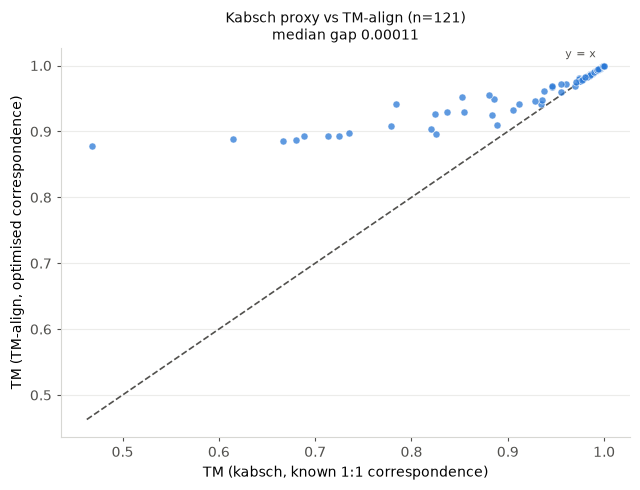

: 

In [ ]:
import csv

def proxy_gap(out_dir=OUT_BA):
    """TM-align vs kabsch on the same pairs. Reads the ledger (fine on a subsample, not at scale)."""
    out_dir = Path(out_dir)
    paths = sorted(out_dir.glob("pairs*.tsv"))
    rows = [r for p in paths for r in csv.DictReader(p.open(), delimiter="\t")
            if r["status"] == "ok" and r.get("tm_kabsch")]
    if not rows:
        print("no rows with both metrics -- re-run score_ba(metric='both')")
        return
    tm = np.array([float(r["tm_min"]) for r in rows])
    kb = np.array([float(r["tm_kabsch"]) for r in rows])
    gap = tm - kb
    inert = gap[tm > 0.99]
    print(f"n={len(rows)}   gap (tm_align - kabsch):  median={np.median(gap):+.5f}  "
          f"mean={gap.mean():+.5f}  min={gap.min():+.5f}  max={gap.max():+.5f}")
    if inert.size:
        print(f"  on the {inert.size} inert pairs (TM>0.99) -- the regime --metric auto uses kabsch "
              f"in -- max |gap| = {np.abs(inert).max():.5f}")
    print(f"  verdict: metric choice is {'IMMATERIAL' if np.abs(gap).max() < 0.01 else 'MATERIAL'} "
          f"here (max |gap| {np.abs(gap).max():.5f})")

    fig, ax = plt.subplots(figsize=(6.5, 5))
    lo = min(tm.min(), kb.min()) - 0.005
    ax.plot([lo, 1.0], [lo, 1.0], color=MUTED, ls="--", lw=1.2, zorder=1)
    ax.annotate("y = x", (1.0, 1.0), textcoords="offset points", xytext=(-28, 6),
                fontsize=8, color=MUTED)
    ax.scatter(kb, tm, s=26, color=BLUE, alpha=.75, linewidths=.5, edgecolors="white", zorder=2)
    ax.set_xlabel("TM (kabsch, known 1:1 correspondence)")
    ax.set_ylabel("TM (TM-align, optimised correspondence)")
    ax.set_title(f"Kabsch proxy vs TM-align (n={len(rows)})\nmedian gap {np.median(gap):.5f}",
                 fontsize=10, color=INK)
    _tidy(ax)
    fig.tight_layout(); plt.show()

proxy_gap()

## 3. Scale-up to the full centroid set

Same script, same flags — only `--shard K/N` is added, so one command fans across a fleet. Each
worker writes `pairs.shardKofN.tsv` + `aggregates.shardKofN.json` and (with `--s3-out`) mirrors both,
so an interrupted or replaced instance resumes from its own ledger without touching anyone else's.

The cell below prints the concrete commands and extrapolates the cost from **this run's measured
throughput** rather than a guess. Workflow at scale:

1. run the shards (fleet, or sequentially on one box);
2. `--merge` the shard aggregates into `aggregates.merged.json`;
3. re-run `plot_ba()` — it picks up the merged file automatically and the figures are unchanged.

In [ ]:
def scale_plan(out_dir=OUT_BA, n_full=630_000, shards=8, metric="auto"):
    """Print the sharded commands + a cost extrapolation from THIS run's measured rate."""
    d = load_agg(out_dir)
    n, elapsed = d["n_ok"], d.get("meta", {}).get("elapsed_s") or 0
    rate = n / elapsed if elapsed else float("nan")
    print(f"measured: {n} pairs in {elapsed:.1f}s  ->  {rate:.1f} pairs/s "
          f"({d.get('meta',{}).get('metric')}, {d.get('meta',{}).get('parser')} parser)\n")
    if rate == rate:
        core_h = n_full / rate / 3600
        print(f"extrapolated to {n_full:,} pairs:  {core_h:.1f} h on this many workers x1, "
              f"or ~{core_h/shards:.1f} h across {shards} shards")
        print(f"  (+ {2*n_full:,} S3 GETs ~= ${2*n_full*0.0004/1000:.2f}; in-region transfer is free)")
        print("  NOTE this is an UPPER bound on wall time, for two reasons:")
        print("    - throughput above was measured over a home connection; an in-region EC2 box is")
        print("      substantially faster on the S3 GETs that dominate the cheap-metric path;")
        if (d.get("meta", {}).get("metric") or "") in ("both", "tmalign") and metric in ("auto", "kabsch"):
            print(f"    - it was measured with --metric {d['meta']['metric']}, but the plan below uses")
            print(f"      --metric {metric}. TM-align is ~cubic in length and ~1000x kabsch's cost, so")
            print("      the real rate will be far higher (the run becomes purely S3-bound).")
        print()
    print("# 1) run the shards (each on its own worker; K is 1-based)")
    for k in (1, 2):
        print(f"python pair_tm.py --run-a {S3_RUN_A} --run-b {S3_RUN_B} \\\n"
              f"    --label-a {LABEL_A} --label-b {LABEL_B} --out {out_dir.name} \\\n"
              f"    --metric {metric} --workers 64 --shard {k}/{shards} \\\n"
              f"    --s3-out s3://petadex-protein-structures/esmfold2-6b/{out_dir.name}/")
    print(f"#    ... through --shard {shards}/{shards}   (or set $PAIRTM_SHARD from instance user-data)")
    print("\n# 2) combine the shard aggregates, then re-run plot_ba()")
    print(f"python pair_tm.py --out {out_dir.name} --merge")

scale_plan()

# Bb / Bc — MolProbity

**Bb.** *Does MSA affect molecular feasibility distributions?* — overlaid distributions of
Molprobity(base_pred) and Molprobity(msa_pred).

**Bc.** *Does MSA affect molecular feasibility (pointwise)?* — x = Molprobity(base_pred),
y = Molprobity(msa_pred); want points **below** y = x, since lower MolProbity is better. Same data as
Bb, read pairwise.

---

## What MolProbity measures

MolProbity scores **geometry**, not correctness: whether bond lengths, angles, rotamers and atomic
contacts are physically plausible. A confidently *wrong* fold can be geometrically immaculate — this
is a feasibility check, not an accuracy one. Lower is better; 0.5 is the floor.

$$\text{MPscore} = 0.426\ln(1{+}\text{clash}) + 0.33\ln(1{+}\max(0,\text{rota}_{out}{-}1)) + 0.25\ln(1{+}\max(0,\text{rama}_{iffy}{-}2)) + 0.5$$

All three components are required — **there is no partial MolProbity score**, so a structure missing
any one of them is recorded as `incomplete` rather than given a number.

## Why a VM rather than a conda install

`conda install cctbx-base` installs the *code* but none of the reference data (`geostd`,
`rotarama_data`, `chemical_components`) and neither of the `probe`/`reduce` binaries — and each
missing piece breaks a different component of the score. MolProbity's `install_via_bootstrap.sh`
pulls all of them together, so a one-off source build on a disposable VM is both simpler and more
reproducible than assembling the parts by hand. It also keeps cctbx out of `igem-alex`, where it
would displace the `numpy`/`matplotlib` versions pinned in §0.

## The VM

**c7i.4xlarge** (16 vCPU) · **Ubuntu 24.04** · **50 GiB gp3** · **us-east-1** — the same region as the
bucket, so structures stream fast and transfer is free. S3 access via an **IAM instance role**, so no
credentials are pasted anywhere.

```bash
# 0. dependencies. python-is-python3 is NOT optional: without it the bootstrap
#    dies at line 46 with "python: command not found"
sudo apt update && sudo apt install -y build-essential python-is-python3 wget

# 1. build -- 30-90 min, dominated by Boost.Python template compilation
wget https://raw.githubusercontent.com/rlabduke/MolProbity/master/install_via_bootstrap.sh
chmod +x install_via_bootstrap.sh
./install_via_bootstrap.sh 16

# 2. put the tools on PATH (add to ~/.bashrc; a fresh shell loses them)
source ~/molprobity/build/setpaths.sh
```

Gotchas, all hit for real:

| | |
|---|---|
| `~/molprobity/molprobity/setup.sh` | the **PHP web interface** — skip it, it is unrelated to the command-line tools |
| interpreter | **`mmtbx.python`**, not `molprobity.python` — no such dispatcher exists in this build |
| `chem_data/` | ships `geostd` + `rotarama_data` but **not** `chemical_components`, so `reduce2`/`clashscore2` are unavailable and clashscore **v1** is the working path |
| apt crawling | `us-east-1.ec2.archive.ubuntu.com` was degraded (222 KB/s, against 12.8 MB/s from S3 on the same box). Use `archive.ubuntu.com` and force IPv4 |

Snapshot the finished instance to an **AMI** — there is no reason to repeat a 90-minute build.

## How `molprobity_test.tsv` was produced

`molprobity_score.py` streams each structure from S3, scores it in-process with cctbx (`--engine api`;
the `cli` engine pays 1–3 s of interpreter startup per structure and fails on JSON parsing anyway),
and appends to a resumable TSV.

```bash
scp -i <key>.pem molprobity_score.py ubuntu@<vm>:~/
mmtbx.python -m pip install boto3

# verify the engine on ONE structure before committing to a batch
mmtbx.python ~/molprobity_score.py --check-env \
    --run base=s3://petadex-protein-structures/esmfold2_paramsweep/s100_l20/

mmtbx.python ~/molprobity_score.py \
    --run base=s3://petadex-protein-structures/esmfold2_paramsweep/s100_l20/ \
    --run msa=s3://petadex-protein-structures/esmfold2_paramsweep/s32_l5/ \
    --out mp_proc --workers 16
```

**242/242 structures scored in 141.2 s (1.71/s).** The ledger was copied back to
`resources/260729_issue6b_folddistributions/molprobity_test.tsv`, which is what the cells below read.

> **cctbx is not thread-safe.** The same job on a `ThreadPoolExecutor` ran effectively serially
> (16 threads ≈ 4 threads ≈ 4.2 s/structure) *and* failed 3 of 242 structures sporadically. With
> processes it scored 242/242, 7.2× faster, and the 239 scores shared with the threaded run were
> byte-identical — so threading broke structures outright rather than silently corrupting the
> survivors. `--pool process` is now the default.


## 4. Reading a MolProbity ledger

Everything below works on **any** `molprobity_score.py` output — point `MP_TSV` at a different ledger
(a bigger run, a different pair of prefixes, a merged set of shards) and every figure and number
re-derives. Nothing is hard-coded to this run.

### Why this is a sample, not a census

MolProbity runs at a measured **1.71 structures/s** on one c7i.4xlarge (16 processes). That makes a
full census affordable but pointless, because the paired difference is already resolved at small n:

| n pairs | smallest difference detectable at 80% power | cost of the MolProbity run |
|---|---|---|
| 121 (this run) | 0.046 | minutes |
| 5,000 | 0.0072 | ~$1, 6 min on 16 boxes |
| 50,000 | 0.0023 | ~$12, 1 h on 16 boxes |
| 630,000 (all centroids) | 0.0007 | ~$150, 13 h on 16 boxes |

The score's spread **across structures is sd ≈ 0.23**, so n = 121 already resolves ~0.2 sd and 50k
resolves 0.01 sd — precision far below any difference that would change a decision. Past a few
thousand pairs the extra n buys decimal places, not insight; what limits the claim is whether the
sampled ORFs are **representative**, and more of the same sampling does not fix that.

So Bb/Bc are answered on a sample. The full centroid set gets folded for 6d and reported with the
**predicted** confidence measures that come free with folding (pLDDT/PAE) — no second geometry
metric, and no cheap MolProbity approximation, is needed anywhere in the pipeline.

> **What these numbers are.** MolProbity scores **geometry** — are bonds, angles, rotamers and atomic
> contacts physically plausible. It says nothing about whether the fold is *correct*. A confidently
> wrong structure can be geometrically immaculate. Lower is better; ~0.5 is the floor.

In [3]:
import csv
import math
import statistics
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

# Palette + axis styling, repeated from 2c (identical values) so this section runs on its own --
# only the config cell in 1 is needed above it.
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seqblue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def _tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)
    for s in ax.spines.values():
        s.set_color("#d7d7d3")
    ax.tick_params(colors=MUTED, length=3)
    ax.grid(axis="y", color="#ececea", lw=0.8)
    ax.set_axisbelow(True)


# --- point this at ANY molprobity_score.py ledger -------------------------------------------------
MP_TSV = RES / "molprobity_test.tsv"

MP_NUM = ("molprobity_score", "clashscore", "pct_rota_outliers",
          "pct_rama_favored", "pct_rama_outliers", "n_res", "wall_s")


def load_mp(tsv=MP_TSV, label_a=LABEL_A, label_b=LABEL_B):
    """Ledger -> {'runs': {label: {col: array}}, 'pairs': {...}}, keeping only status == 'ok'.

    Pairs are formed on ORFid, so a structure that failed in one run drops that pair from BOTH --
    which is what Bc requires and what a naive per-run comparison would silently get wrong.
    """
    tsv = Path(tsv)
    with open(tsv, newline="") as fh:
        rows = list(csv.DictReader(fh, delimiter="\t"))
    ok = [r for r in rows if r.get("status") == "ok"]
    labels = [l for l in (label_a, label_b) if any(r["run"] == l for r in ok)]
    labels += sorted({r["run"] for r in ok} - set(labels))

    runs = {}
    for lab in labels:
        sel = [r for r in ok if r["run"] == lab]
        runs[lab] = {c: np.array([float(r[c]) for r in sel if r.get(c) not in ("", None)])
                     for c in MP_NUM}
        runs[lab]["orfid"] = np.array([r["orfid"] for r in sel])

    by = {}
    for r in ok:
        by.setdefault(r["orfid"], {})[r["run"]] = r
    a, b = labels[0], labels[1] if len(labels) > 1 else labels[0]
    shared = sorted(o for o, v in by.items() if a in v and b in v)
    pairs = {"orfid": np.array(shared)}
    for c in MP_NUM:
        pairs[c + "_a"] = np.array([float(by[o][a][c]) for o in shared])
        pairs[c + "_b"] = np.array([float(by[o][b][c]) for o in shared])
    pairs["diff"] = pairs["molprobity_score_b"] - pairs["molprobity_score_a"]

    d = {"tsv": tsv, "runs": runs, "labels": labels, "pairs": pairs,
         "n_rows": len(rows), "n_ok": len(ok),
         "status": dict(sorted({s: sum(1 for r in rows if r.get("status") == s)
                                for s in {r.get("status") for r in rows}}.items()))}
    return d


def summarise_mp(d=None):
    """Per-run table + the paired inference. Reports both metrics side by side for every run."""
    d = d or load_mp()
    p, (a, b) = d["pairs"], (d["labels"][0], d["labels"][1])
    print(f"{d['tsv'].name}: {d['n_rows']} rows, {d['n_ok']} ok  "
          f"({', '.join(f'{k}={v}' for k, v in d['status'].items() if k)})")
    print(f"{len(p['orfid'])} ORFs scored in BOTH runs\n")

    hdr = f"  {'run':<8s}{'n':>5s}{'MolProbity':>22s}{'clashscore':>14s}{'rota out%':>12s}{'rama fav%':>12s}"
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for lab in d["labels"]:
        r = d["runs"][lab]
        s = r["molprobity_score"]
        print(f"  {lab:<8s}{len(s):>5d}"
              f"{statistics.median(s):>12.3f} ±{statistics.stdev(s):<8.3f}"
              f"{statistics.median(r['clashscore']):>14.2f}"
              f"{statistics.median(r['pct_rota_outliers']):>12.2f}"
              f"{statistics.median(r['pct_rama_favored']):>12.2f}")
    print("  (median ± sd; lower MolProbity is better, floor 0.5)")

    diff, n = p["diff"], len(p["diff"])
    if n > 1:
        mean, sd = statistics.fmean(diff), statistics.stdev(diff)
        se = sd / math.sqrt(n)
        better = int((diff < 0).sum())
        print(f"\n  paired difference ({b} - {a}), n={n}")
        print(f"    mean {mean:+.4f}   sd {sd:.4f}   95% CI [{mean - 1.96 * se:+.4f}, "
              f"{mean + 1.96 * se:+.4f}]   t {mean / se:+.2f}")
        print(f"    {b} better in {better}/{n} pairs ({100 * better / n:.1f}%)")
        verdict = ("NO detectable difference (CI spans 0)" if (mean - 1.96 * se) * (mean + 1.96 * se) < 0
                   else f"{b} is {'better' if mean < 0 else 'WORSE'} by {abs(mean):.3f} on average")
        print(f"    -> {verdict}")
        print(f"    at this n the smallest detectable true difference is "
              f"{2.8 * sd / math.sqrt(n):.4f}")
    return d


MP = summarise_mp()

molprobity_test.tsv: 242 rows, 242 ok  (ok=242)
121 ORFs scored in BOTH runs

  run         n            MolProbity    clashscore   rota out%   rama fav%
  -------------------------------------------------------------------------
  base      121       1.347 ±0.232             4.82        0.00       97.17
  msa       121       1.398 ±0.229             4.62        0.00       97.24
  (median ± sd; lower MolProbity is better, floor 0.5)

  paired difference (msa - base), n=121
    mean +0.0265   sd 0.1809   95% CI [-0.0058, +0.0587]   t +1.61
    msa better in 52/121 pairs (43.0%)
    -> NO detectable difference (CI spans 0)
    at this n the smallest detectable true difference is 0.0461


### 4a. Figure Bb — do the distributions differ?

Overlaid distributions of MolProbity(base) and MolProbity(msa), plus the two components that drive
the score. Distribution-level only: this asks whether the *populations* differ, not whether any
individual ORF improved — that is Bc.

Both runs are shown on every panel, and the components are included because a single summary score
can hide compensating movement (clashes worse, rotamers better, score unchanged).

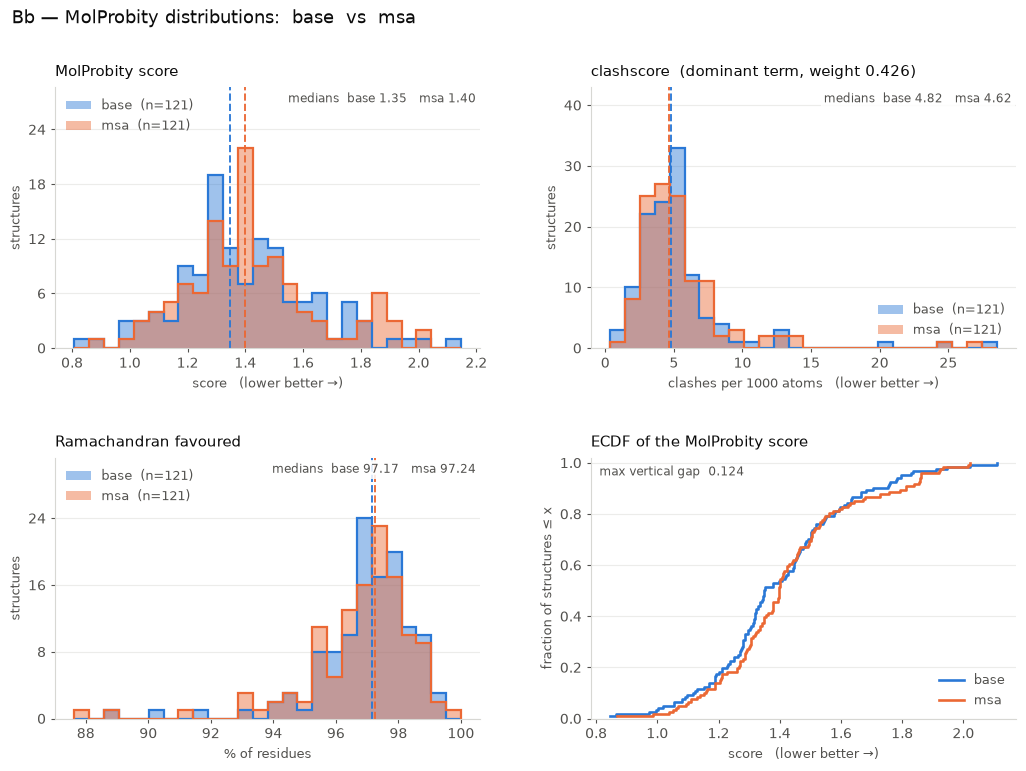

In [4]:
def plot_bb(d=None, save=None):
    d = d or MP
    a, b = d["labels"][0], d["labels"][1]
    ra, rb = d["runs"][a], d["runs"][b]

    fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.2))
    fig.subplots_adjust(hspace=0.42, wspace=0.26)

    def overlay(ax, key, title, xlabel, nbins=26, better_low=True):
        va, vb = ra[key], rb[key]
        lo, hi = float(min(va.min(), vb.min())), float(max(va.max(), vb.max()))
        pad = 0.03 * (hi - lo) if hi > lo else 1.0
        edges = np.linspace(lo - pad, hi + pad, nbins + 1)
        for v, c, lab in ((va, BLUE, a), (vb, ORANGE, b)):
            ax.hist(v, bins=edges, color=c, alpha=0.45, label=f"{lab}  (n={len(v)})")
            ax.hist(v, bins=edges, histtype="step", color=c, lw=1.6)
        for v, c in ((va, BLUE), (vb, ORANGE)):
            ax.axvline(np.median(v), color=c, ls="--", lw=1.4, alpha=0.95)
        _tidy(ax)
        ax.set_title(title, color=INK, fontsize=11, loc="left", pad=8)
        ax.set_xlabel(xlabel + ("   (lower better →)" if better_low else ""),
                      color=MUTED, fontsize=9)
        ax.set_ylabel("structures", color=MUTED, fontsize=9)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.24)          # headroom, else the label sits on the bars
        # the median rules can land anywhere, so the label carries its own background
        ax.text(0.99, 0.98, f"medians  {a} {np.median(va):.2f}   {b} {np.median(vb):.2f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=MUTED,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2))

    overlay(axes[0][0], "molprobity_score", "MolProbity score", "score")
    overlay(axes[0][1], "clashscore", "clashscore  (dominant term, weight 0.426)",
            "clashes per 1000 atoms")
    overlay(axes[1][0], "pct_rama_favored", "Ramachandran favoured", "% of residues",
            better_low=False)

    # ECDF: the cleanest read on whether one distribution dominates the other
    ax = axes[1][1]
    for v, c, lab in ((ra["molprobity_score"], BLUE, a), (rb["molprobity_score"], ORANGE, b)):
        x = np.sort(v)
        ax.step(x, np.arange(1, len(x) + 1) / len(x), color=c, lw=1.9, where="post", label=lab)
    _tidy(ax)
    ax.set_title("ECDF of the MolProbity score", color=INK, fontsize=11, loc="left", pad=8)
    ax.set_xlabel("score   (lower better →)", color=MUTED, fontsize=9)
    ax.set_ylabel("fraction of structures ≤ x", color=MUTED, fontsize=9)
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="lower right")
    # A curve fully to the LEFT is uniformly better; crossing curves mean it depends on the ORF.
    # The gap is the KS statistic: evaluate BOTH ECDFs on the union of the samples, since the
    # supremum can be attained at a point of either one.
    va, vb = ra["molprobity_score"], rb["molprobity_score"]
    allx = np.union1d(va, vb)
    fa = np.searchsorted(np.sort(va), allx, side="right") / len(va)
    fb = np.searchsorted(np.sort(vb), allx, side="right") / len(vb)
    ax.text(0.02, 0.97, f"max vertical gap  {np.abs(fa - fb).max():.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=8.5, color=MUTED)

    fig.suptitle(f"Bb — MolProbity distributions:  {a}  vs  {b}", color=INK, fontsize=13,
                 x=0.09, ha="left", y=0.975)
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


plot_bb()

### 4b. Figure Bc — did individual ORFs improve?

x = MolProbity(base), y = MolProbity(msa), one point per ORF folded by both. Lower is better, so
points **below the diagonal** are ORFs the second run improved. The paired difference removes
per-ORF difficulty, which is why this is far more sensitive than comparing the two distributions in
Bb — the same protein is its own control.

The right panel is the actual inference: the distribution of per-ORF differences, with the mean and
its 95% confidence interval. If that interval spans zero, the runs are indistinguishable regardless
of how different the clouds look.

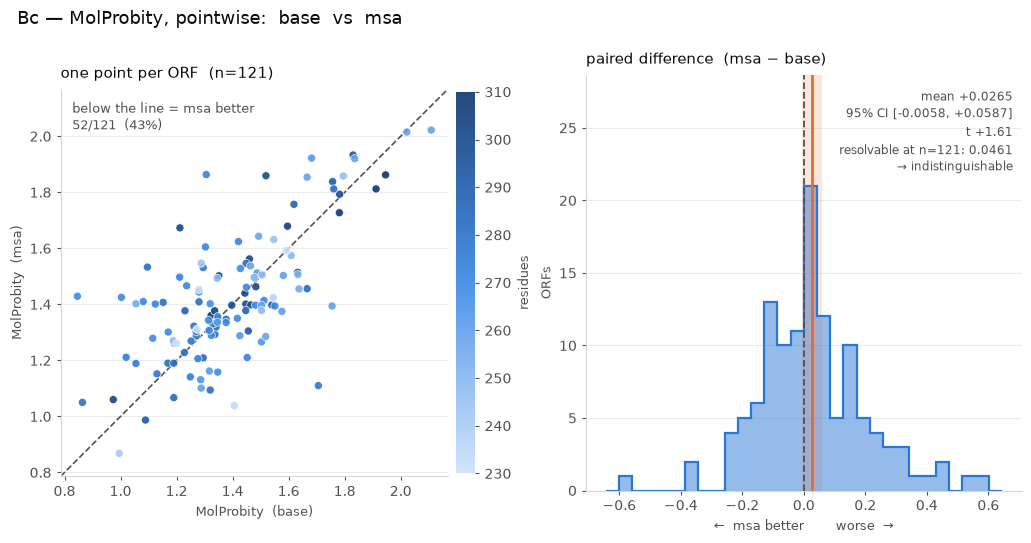

In [5]:
def plot_bc(d=None, save=None):
    d = d or MP
    p = d["pairs"]
    a, b = d["labels"][0], d["labels"][1]
    xa, yb, diff = p["molprobity_score_a"], p["molprobity_score_b"], p["diff"]
    n = len(diff)

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.4),
                                  gridspec_kw={"width_ratios": [1.0, 1.05]})
    fig.subplots_adjust(wspace=0.26)

    # --- left: paired scatter, coloured by size so a length effect would be visible -------------
    lo = float(min(xa.min(), yb.min())) - 0.06
    hi = float(max(xa.max(), yb.max())) + 0.06
    ax.plot([lo, hi], [lo, hi], color=MUTED, lw=1.2, ls="--", zorder=1)
    sc = ax.scatter(xa, yb, c=p["n_res_a"], cmap=SEQ_BLUE, s=34, alpha=0.9,
                    edgecolor="white", linewidth=0.5, zorder=3)
    cb = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label("residues", color=MUTED, fontsize=9)
    cb.ax.tick_params(colors=MUTED, length=3)
    cb.outline.set_visible(False)
    _tidy(ax)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel(f"MolProbity  ({a})", color=MUTED, fontsize=9)
    ax.set_ylabel(f"MolProbity  ({b})", color=MUTED, fontsize=9)
    ax.set_title(f"one point per ORF  (n={n})", color=INK, fontsize=11, loc="left", pad=8)
    better = int((diff < 0).sum())
    ax.text(0.03, 0.97, f"below the line = {b} better\n{better}/{n}  ({100 * better / n:.0f}%)",
            transform=ax.transAxes, ha="left", va="top", fontsize=9, color=MUTED)

    # --- right: the paired difference, which is the actual inference -----------------------------
    mean, sd = float(diff.mean()), float(diff.std(ddof=1))
    se = sd / math.sqrt(n)
    ci = (mean - 1.96 * se, mean + 1.96 * se)
    lim = float(np.abs(diff).max()) * 1.08
    ax2.hist(diff, bins=np.linspace(-lim, lim, 31), color=BLUE, alpha=0.5)
    ax2.hist(diff, bins=np.linspace(-lim, lim, 31), histtype="step", color=BLUE, lw=1.6)
    ax2.axvline(0.0, color=MUTED, lw=1.3, ls="--")
    ax2.axvline(mean, color=ORANGE, lw=2.0)
    ax2.axvspan(ci[0], ci[1], color=ORANGE, alpha=0.16, lw=0)
    _tidy(ax2)
    ax2.set_title(f"paired difference  ({b} − {a})", color=INK, fontsize=11, loc="left", pad=8)
    ax2.set_xlabel(f"←  {b} better        worse  →", color=MUTED, fontsize=9)
    ax2.set_ylabel("ORFs", color=MUTED, fontsize=9)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax2.set_ylim(0, ax2.get_ylim()[1] * 1.3)             # headroom for the stats block
    spans_zero = ci[0] * ci[1] < 0
    ax2.text(0.98, 0.97,
             f"mean {mean:+.4f}\n95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]\n"
             f"t {mean / se:+.2f}\nresolvable at n={n}: {2.8 * sd / math.sqrt(n):.4f}\n"
             + ("→ indistinguishable" if spans_zero else
                f"→ {b} {'better' if mean < 0 else 'worse'}"),
             transform=ax2.transAxes, ha="right", va="top", fontsize=8.5, color=MUTED,
             linespacing=1.5)

    fig.suptitle(f"Bc — MolProbity, pointwise:  {a}  vs  {b}", color=INK, fontsize=13,
                 x=0.09, ha="left", y=1.0)
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


plot_bc()

# Conclusions

*(To be written once the MSA folds exist.)* The figures above were produced from two **param-config**
runs standing in for base-vs-MSA, so they validate the pipeline, not the biology — 6a already showed
those two configs agree to TM ≈ 0.99, so a spike at 1.0 here is the tooling working, not a result
about MSAs.